In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("titanic.csv")

In [4]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [ ]:
import seaborn as sns

## Сколько выжило, а сколько погибло

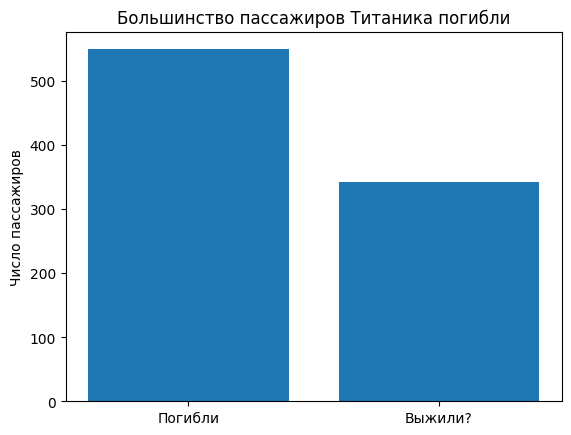

In [7]:
# считаем число погибших (0) и выживших (1)
counts = df["Survived"].value_counts()

plt.bar(["Погибли", "Выжили?"], counts[[0, 1]])
plt.title("Большинство пассажиров Титаника погибли")
plt.ylabel("Число пассажиров")
plt.show()

## Доля выживших: мужчины и женщины

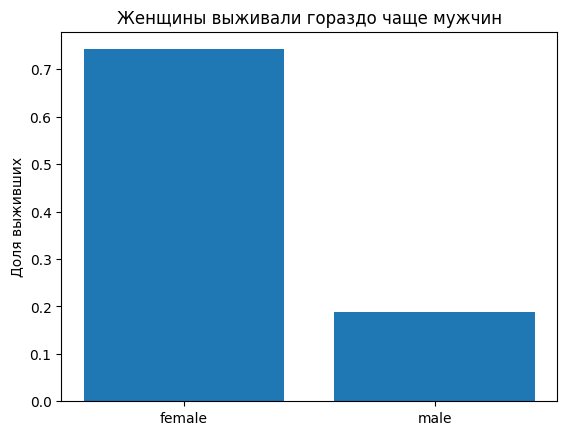

In [9]:
# средняя выживаемость по полу (Survived = доля выживших)
rate = df.groupby("Sex")["Survived"].mean()

plt.bar(rate.index, rate.values)
plt.title("Женщины выживали гораздо чаще мужчин")
plt.ylabel("Доля выживших")
plt.show()

## Доля выживших по классу каюты

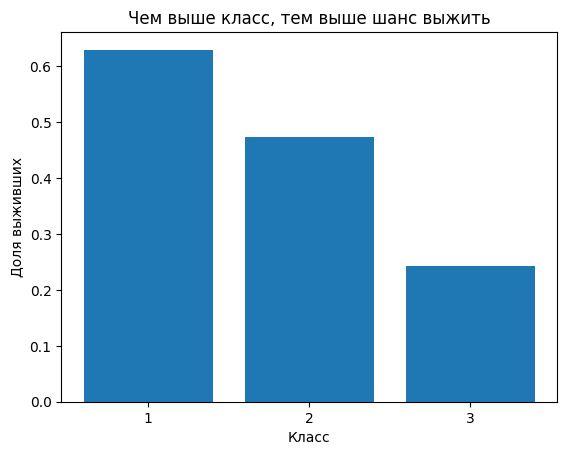

In [11]:
# средняя выживаемость по классу, сортируем по убыванию
rate = df.groupby("Pclass")["Survived"].mean().sort_values(ascending=False)

plt.bar(rate.index.astype(str), rate.values)
plt.title("Чем выше класс, тем выше шанс выжить")
plt.xlabel("Класс")
plt.ylabel("Доля выживших")
plt.show()

## Распределение возраста пассажиров

In [ ]:
# гистограмма возраста: разбиваем на 30 интервалов
plt.hist(df["Age"], bins=30)
plt.title("Большинство пассажиров — молодые взрослые (20–40 лет)")
plt.xlabel("Возраст")
plt.ylabel("Число пассажиров")
plt.show()

## Распределение стоимости билета (Fare)

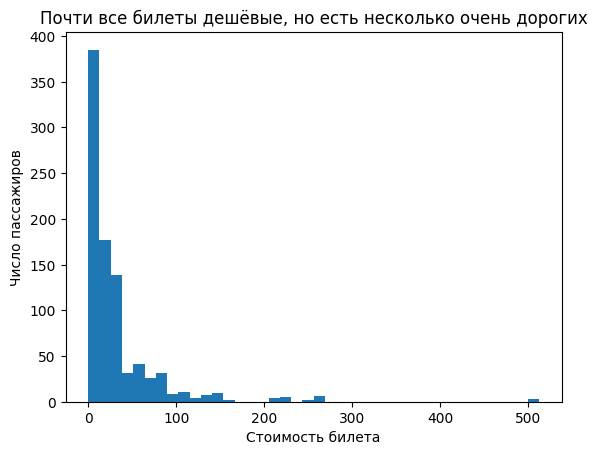

In [15]:
# гистограмма стоимости билета
plt.hist(df["Fare"], bins=40)
plt.title("Почти все билеты дешёвые, но есть несколько очень дорогих")
plt.xlabel("Стоимость билета")
plt.ylabel("Число пассажиров")
plt.show()

## Возраст выживших и погибших на одном графике

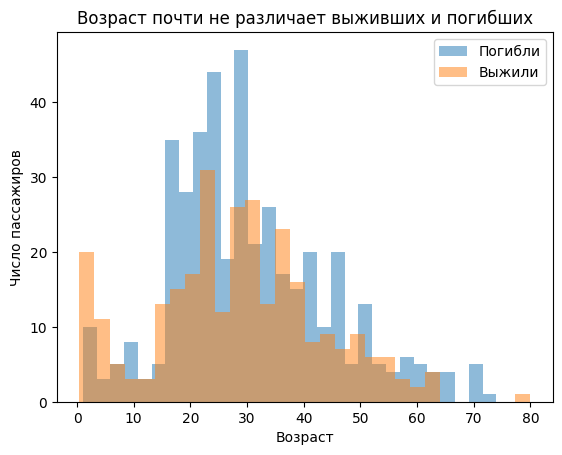

In [21]:
# берём возраст отдельно для выживших и погибших
age_survived = df[df["Survived"] == 1]["Age"]
age_died = df[df["Survived"] == 0]["Age"]

# две полупрозрачные гистограммы на одних осях
plt.hist(age_died, bins=30, alpha=0.5, label="Погибли")
plt.hist(age_survived, bins=30, alpha=0.5, label="Выжили")
plt.title("Возраст почти не различает выживших и погибших")
plt.xlabel("Возраст")
plt.ylabel("Число пассажиров")
plt.legend()
plt.show()

## Стоимость билета по классам — box plot

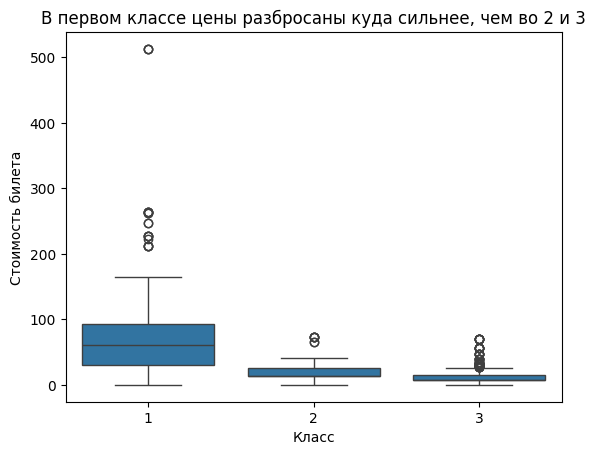

In [22]:
# box plot стоимости билета внутри каждого класса
sns.boxplot(data=df, x="Pclass", y="Fare")
plt.title("В первом классе цены разбросаны куда сильнее, чем во 2 и 3")
plt.xlabel("Класс")
plt.ylabel("Стоимость билета")
plt.show()

## Выживаемость по классу и полу вместе

In [ ]:
# доля выживших по классу, отдельными столбцами для каждого пола
sns.barplot(data=df, x="Pclass", y="Survived", hue="Sex")
plt.title("Женщины 1 и 2 класса выживали почти все")
plt.xlabel("Класс")
plt.ylabel("Доля выживших")
plt.show()

## Возраст и стоимость билета, цвет — выживание

In [ ]:
# точки: возраст по x, стоимость билета по y, цвет — выжил или нет
sns.scatterplot(data=df, x="Age", y="Fare", hue="Survived")
plt.title("Среди дорогих билетов выживших заметно больше")
plt.xlabel("Возраст")
plt.ylabel("Стоимость билета")
plt.show()

## Тепловая карта: доля выживших по классу и полу

In [ ]:
# таблица: доля выживших для каждой пары (пол, класс)
table = df.pivot_table(values="Survived", index="Sex", columns="Pclass")

sns.heatmap(table, annot=True, cmap="YlGnBu")
plt.title("Пол и класс вместе решают почти всё")
plt.xlabel("Класс")
plt.ylabel("Пол")
plt.show()

## Выделяем главный столбец — 1 класс

In [ ]:
# та же выживаемость по классу, отсортированная
rate = df.groupby("Pclass")["Survived"].mean().sort_values(ascending=False)

# все столбцы серые, кроме первого класса — он оранжевый
colors = ["orange" if c == 1 else "lightgray" for c in rate.index]

plt.bar(rate.index.astype(str), rate.values, color=colors)
plt.title("В 1 классе выжило больше половины — остальные сильно ниже")
plt.xlabel("Класс")
plt.ylabel("Доля выживших")
plt.show()

## История из 3 графиков: кто выжил на Титанике

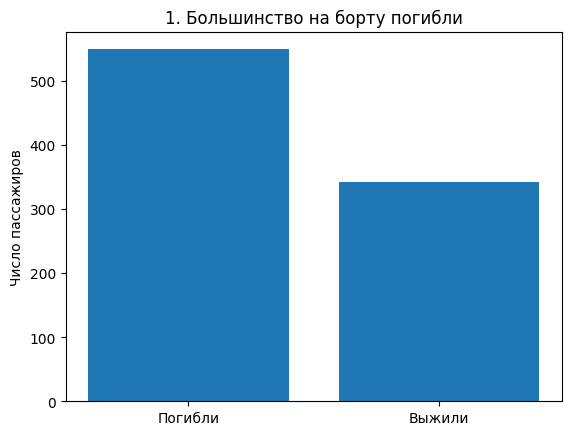

In [28]:
# График 1: большинство пассажиров погибли
counts = df["Survived"].value_counts()

plt.bar(["Погибли", "Выжили"], counts[[0, 1]])
plt.title("1. Большинство на борту погибли")
plt.ylabel("Число пассажиров")
plt.show()

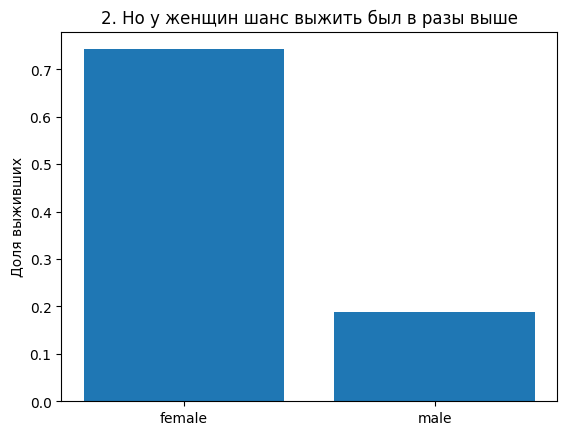

In [29]:
# График 2: но выживаемость резко зависела от пола
rate = df.groupby("Sex")["Survived"].mean()

plt.bar(rate.index, rate.values)
plt.title("2. Но у женщин шанс выжить был в разы выше")
plt.ylabel("Доля выживших")
plt.show()

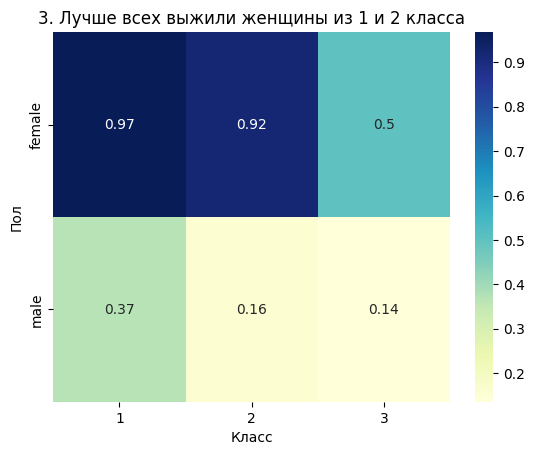

In [27]:
# График 3: и пол, и класс вместе — кульминация
table = df.pivot_table(values="Survived", index="Sex", columns="Pclass")

sns.heatmap(table, annot=True, cmap="YlGnBu")
plt.title("3. Лучше всех выжили женщины из 1 и 2 класса")
plt.xlabel("Класс")
plt.ylabel("Пол")
plt.show()